## 05 — Census-tract subset

Identify all census tracts that contain at least one UDU parcel, then subset
the full LA City assessor master down to parcels within those tracts.

**Output**: `data/03_processed/assessor_udu_tracts.gpkg`
  - layer `parcels`  — all AINs (any use type) in UDU-containing tracts
  - layer `tracts`   — the UDU census tract polygons with UDU count per tract

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

os.chdir('../..')
print(f"Working directory: {os.getcwd()}")

MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
UDU_PATH     = 'data/01_raw/UDU Report 02_10_2026.csv'
BLOCKS_PATH  = '/Users/adamswietek/Documents/PostDoc/data/raw_national/tlgdb_2024_a_us_block.gdb'
OUTPUT_PATH  = 'data/03_processed/assessor_udu_tracts.gpkg'

UTM_CRS = 32611   # UTM Zone 11N, metres

def normalize_ain(s):
    return str(s).strip().replace('-', '')

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing


### 1. Load UDU AINs

In [2]:
udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = set(
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
print(f'{len(udu_ains):,} UDU AINs loaded')
udu_raw.head(3)

442 UDU AINs loaded


,case_number,assessor_parcel_number,general_plan_land_use,community_plan_area,specific_plan,filing_date,case_completion_date,Approved Units
0,ADM-2017-4524-UDU,4313010033,Medium Residential,Palms - Mar Vista - Del Rey,West Los Angeles Transportation Improvement an...,2017-06-08 00:00:00,2017-06-30 00:00:00,6.0
1,ADM-2017-4592-UDU,4294002011,Medium Residential,Venice,"Los Angeles Coastal Transportation Corridor,Ve...",2017-11-08 00:00:00,2021-04-15 00:00:00,2.0
2,ADM-2017-4593-UDU,4294009028,Medium Residential,Venice,"Los Angeles Coastal Transportation Corridor,Ve...",2017-11-08 00:00:00,2017-09-25 00:00:00,2.0


### 2. Get UDU parcel geometries from assessor master

In [3]:
# Use 2017 layer as the stable mid-period reference (same as symdiff pipeline)
master = gpd.read_file(MASTER_PATH, layer='2017', columns=['AIN', 'usetype', 'geometry'])
master['AIN'] = master['AIN'].apply(normalize_ain)

udu_parcels = master[master['AIN'].isin(udu_ains)].copy()
print(f'{len(udu_parcels):,} of {len(udu_ains):,} UDU AINs matched to parcel geometry')
print(f'CRS: {udu_parcels.crs}')
udu_parcels.head(3)

439 of 442 UDU AINs matched to parcel geometry
CRS: EPSG:2229


,AIN,usetype,geometry
106,5040024013,Three Units (Any Combination),"POLYGON ((6472182.14 1832067.547, 6472307.14 1..."
971,5054005001,Store Combination,"POLYGON ((6470741.107 1834218.376, 6470736.107..."
1463,5054026019,Four Units (Any Combination),"POLYGON ((6472595.422 1834925.729, 6472545.421..."


### 3. Load census blocks → dissolve to tracts

Source: TIGER/Line 2024 block GDB. Block rows share `TRACTCE + COUNTYFP + STATEFP`;
dissolving on those three fields produces tract polygons.

In [4]:
# Mask the block file to the bounding box of LA County (speeds up load significantly)
la_bbox = udu_parcels.to_crs(4326).total_bounds   # (xmin, ymin, xmax, ymax)
pad = 0.1   # ~10 km buffer to catch edge tracts
la_bbox_padded = la_bbox + np.array([-pad, -pad, pad, pad])

from shapely.geometry import box as shapely_box
mask_geom = gpd.GeoDataFrame(geometry=[shapely_box(*la_bbox_padded)], crs=4326)

print('Loading census blocks (mask = LA bounding box)...')
blocks = gpd.read_file(BLOCKS_PATH, mask=mask_geom)
print(f'  {len(blocks):,} blocks loaded  |  CRS: {blocks.crs}')
print(f'  Columns: {list(blocks.columns)}')

Loading census blocks (mask = LA bounding box)...
  67,384 blocks loaded  |  CRS: EPSG:4269
  Columns: ['GEOID20', 'GEOIDFQ20', 'SUFFIX', 'NAME', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [5]:
# TIGER block GEOID20 is 15 chars: SS + CCC + TTTTTT + BBBB
# First 11 chars (state + county + tract) uniquely identify the tract.
blocks['GEOID_TRACT'] = blocks['GEOID20'].astype(str).str[:11]

tracts = (
    blocks
    .dissolve('GEOID_TRACT')[['geometry']]
    .reset_index()
)
tracts['geometry'] = tracts['geometry'].make_valid()
print(f'{len(tracts):,} census tracts after dissolve')
tracts.head(3)

2,058 census tracts after dissolve


,GEOID_TRACT,geometry
0,06037101110,"POLYGON ((-118.30098 34.25744, -118.30229 34.2..."
1,06037101122,"POLYGON ((-118.29007 34.26284, -118.29131 34.2..."
2,06037101220,"POLYGON ((-118.2842 34.24792, -118.28592 34.24..."


### 4. Spatial join: find census tracts containing at least one UDU parcel

In [6]:
# Use representative points of UDU parcels to avoid edge-case double-assignment
udu_pts = udu_parcels.copy()
udu_pts['geometry'] = (
    udu_pts.to_crs(UTM_CRS).representative_point().to_crs(udu_parcels.crs)
)

tracts_aligned = tracts.to_crs(udu_pts.crs)

joined = gpd.sjoin(
    udu_pts[['AIN', 'geometry']],
    tracts_aligned[['GEOID_TRACT', 'geometry']],
    how='left',
    predicate='within'
)

udu_tract_counts = (
    joined
    .dropna(subset=['GEOID_TRACT'])
    .groupby('GEOID_TRACT')['AIN']
    .nunique()
    .rename('n_udu')
    .reset_index()
)

print(f'{joined["GEOID_TRACT"].notna().sum():,} of {len(udu_pts):,} UDU parcels matched to a tract')
print(f'{len(udu_tract_counts):,} census tracts contain at least one UDU')
udu_tract_counts['n_udu'].describe().to_frame().T

439 of 439 UDU parcels matched to a tract
301 census tracts contain at least one UDU


,count,mean,std,min,25%,50%,75%,max
n_udu,301.0,1.458472,0.981038,1.0,1.0,1.0,2.0,12.0


In [7]:
# Attach UDU counts back to tract polygons
udu_tracts = tracts_aligned.merge(udu_tract_counts, on='GEOID_TRACT', how='inner')
print(f'UDU tract GDF: {len(udu_tracts):,} rows  |  CRS: {udu_tracts.crs}')

udu_tract_ids = set(udu_tracts['GEOID_TRACT'])
print(f'Unique GEOID_TRACTs: {len(udu_tract_ids):,}')

UDU tract GDF: 301 rows  |  CRS: EPSG:2229
Unique GEOID_TRACTs: 301


### 5. Subset assessor master to UDU-containing tracts

In [8]:
# Use the dissolved tract union as a spatial mask to pre-filter the master read
tract_union = udu_tracts.dissolve()[['geometry']]

master_full = gpd.read_file(MASTER_PATH, layer='2017', mask=tract_union.to_crs(master.crs))
master_full['AIN'] = master_full['AIN'].apply(normalize_ain)
print(f'Parcels in UDU-tract bbox after mask: {len(master_full):,}')

# Precise point-in-polygon: assign each parcel its GEOID_TRACT
master_pts = master_full.copy()
master_pts['geometry'] = (
    master_pts.to_crs(UTM_CRS).representative_point().to_crs(master_full.crs)
)

master_joined = gpd.sjoin(
    master_pts[['AIN', 'geometry']],
    udu_tracts[['GEOID_TRACT', 'n_udu', 'geometry']],
    how='inner',
    predicate='within'
).drop_duplicates('AIN')

# Restore original polygon geometry
parcels_udu_tracts = (
    master_full
    .merge(master_joined[['AIN', 'GEOID_TRACT', 'n_udu']], on='AIN', how='inner')
)
parcels_udu_tracts['is_udu'] = parcels_udu_tracts['AIN'].isin(udu_ains)

print(f'Parcels in UDU-containing tracts : {len(parcels_udu_tracts):,}')
print(f'  of which UDU     : {parcels_udu_tracts["is_udu"].sum():,}')
print(f'  of which non-UDU : {(~parcels_udu_tracts["is_udu"]).sum():,}')
parcels_udu_tracts.groupby('usetype').size().sort_values(ascending=False).head(10)

Parcels in UDU-tract bbox after mask: 164,607
Parcels in UDU-containing tracts : 163,921
  of which UDU     : 439
  of which non-UDU : 163,482


usetype
Single Family Residence                               94624
Double, Duplex, or Two Units                          21841
Five or More Units or Apartments (Any Combination)    13427
Three Units (Any Combination)                          7682
Four Units  (Any Combination)                          7172
Store                                                  2730
Store Combination                                      2396
Light Manufacturing                                    2168
Parking Lot (Commercial Use Property)                  1684
Government Owned Property                              1331
dtype: int64

### 6. Restrict to mixed-residential tracts

Keep only tracts that contain at least one SFR **and** at least one other residential parcel
(duplex / 3–4 unit / 5+ apartment). This removes purely commercial or high-density-only tracts
that lack the SFR context where UDUs are most likely to form.

In [9]:
# Tag each parcel: SFR / other-residential / non-residential
sfr_mask = parcels_udu_tracts['usetype'].str.contains('Single', case=False, na=False)

other_res_types = {
    'Double, Duplex, or Two Units',
    'Five or More Units or Apartments (Any Combination)',
    'Three Units (Any Combination)',
    'Four Units  (Any Combination)',
}
other_res_mask = parcels_udu_tracts['usetype'].isin(other_res_types) & ~sfr_mask

parcels_udu_tracts['res_category'] = 'non_residential'
parcels_udu_tracts.loc[sfr_mask,       'res_category'] = 'sfr'
parcels_udu_tracts.loc[other_res_mask, 'res_category'] = 'other_residential'

# Identify tracts that have both SFR and other-residential
tract_has_sfr    = set(parcels_udu_tracts.loc[sfr_mask,       'GEOID_TRACT'])
tract_has_other  = set(parcels_udu_tracts.loc[other_res_mask, 'GEOID_TRACT'])
mixed_res_tracts = tract_has_sfr & tract_has_other

print(f'Tracts with SFR only              : {len(tract_has_sfr  - mixed_res_tracts):,}')
print(f'Tracts with other-res only        : {len(tract_has_other - mixed_res_tracts):,}')
print(f'Tracts with both (keeping)        : {len(mixed_res_tracts):,}')

# Apply filter
parcels_udu_tracts = parcels_udu_tracts[
    parcels_udu_tracts['GEOID_TRACT'].isin(mixed_res_tracts)
].copy()
udu_tracts = udu_tracts[udu_tracts['GEOID_TRACT'].isin(mixed_res_tracts)].copy()

print(f'\nFinal sample — {parcels_udu_tracts["GEOID_TRACT"].nunique():,} tracts | '
      f'{len(parcels_udu_tracts):,} parcels '
      f'({parcels_udu_tracts["is_udu"].sum():,} UDU)')
print(parcels_udu_tracts['res_category'].value_counts().to_string())

Tracts with SFR only              : 0
Tracts with other-res only        : 1
Tracts with both (keeping)        : 300

Final sample — 300 tracts | 163,822 parcels (438 UDU)
res_category
sfr                  94624
other_residential    50093
non_residential      19105


### 7. Visualization — UDU tracts choropleth

/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)
/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_61196/69044313.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.8)


Saved -> notebooks/tasks/figures/udu_tracts_map.png


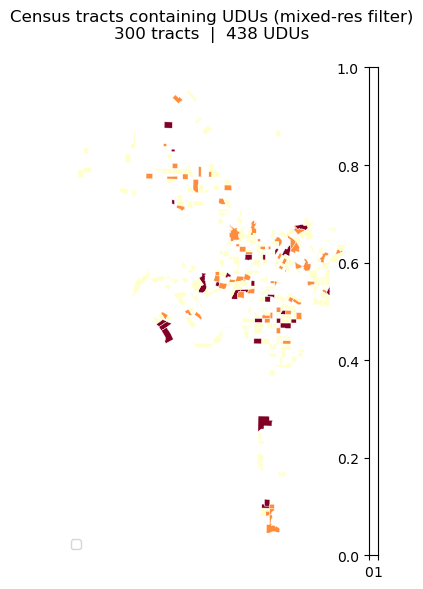

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

plot_tracts = udu_tracts.to_crs(UTM_CRS)

fig, ax = plt.subplots(figsize=(5, 6))

divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad=0.1)

plot_tracts.plot(
    column='n_udu',
    ax=ax,
    cax=cax,
    cmap='YlOrRd',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'UDU count\n(quintiles)', 'fmt': '{:.0f}'},
    edgecolor='white',
    linewidth=0.3,
)

# overlay UDU parcel centroids
udu_pts_plot = (
    udu_parcels[udu_parcels['AIN'].isin(
        parcels_udu_tracts.loc[parcels_udu_tracts['is_udu'], 'AIN']
    )]
    .to_crs(UTM_CRS)
)
udu_pts_plot['geometry'] = udu_pts_plot.representative_point()
# udu_pts_plot.plot(ax=ax, color='steelblue', markersize=10, zorder=3,
#                   label='UDU parcel')

ax.set_axis_off()
ax.set_title(
    f'Census tracts containing UDUs (mixed-res filter)\n'
    f'{len(plot_tracts):,} tracts  |  {int(plot_tracts["n_udu"].sum()):,} UDUs',
    fontsize=12, pad=10
)
ax.legend(loc='lower left', fontsize=9, framealpha=0.8)

plt.tight_layout()

FIG_PATH = 'notebooks/tasks/figures/udu_tracts_map.png'
import os; os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
plt.savefig(FIG_PATH, dpi=150, bbox_inches='tight')
print(f'Saved -> {FIG_PATH}')
plt.show()

### 8. Tract summary table

In [11]:
# ── per-tract summary table ───────────────────────────────────────────────────
# UDU count
udu_counts = (
    parcels_udu_tracts[parcels_udu_tracts['is_udu']]
    .groupby('GEOID_TRACT')['AIN'].nunique()
    .rename('n_udu')
)

# total parcels per tract
total_parcels = (
    parcels_udu_tracts
    .groupby('GEOID_TRACT')['AIN'].nunique()
    .rename('n_parcels')
)

# use-mix counts → pivot to wide
use_mix = (
    parcels_udu_tracts
    .groupby(['GEOID_TRACT', 'res_category'])['AIN']
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={
        'sfr':               'n_sfr',
        'other_residential': 'n_other_res',
        'non_residential':   'n_non_res',
    })
)

tract_summary = (
    total_parcels
    .to_frame()
    .join(udu_counts)
    .join(use_mix)
    .fillna(0)
    .astype({'n_udu': int, 'n_sfr': int, 'n_other_res': int, 'n_non_res': int})
)

# pct shares (of total parcels in tract)
for col, pct_col in [('n_sfr', 'pct_sfr'), ('n_other_res', 'pct_other_res'),
                     ('n_non_res', 'pct_non_res'), ('n_udu', 'pct_udu')]:
    tract_summary[pct_col] = (tract_summary[col] / tract_summary['n_parcels'] * 100).round(1)

col_order = ['n_parcels', 'n_udu', 'pct_udu',
             'pct_sfr', 'pct_non_res','n_other_res', 'n_sfr', 'pct_other_res',
             'n_non_res', ]
tract_summary = tract_summary[col_order].sort_values('n_udu', ascending=False)

print(f'Tract summary: {len(tract_summary):,} tracts\n')
print(tract_summary.describe().round(1).to_string())
tract_summary.head(20)

Tract summary: 300 tracts

       n_parcels  n_udu  pct_udu  pct_sfr  pct_non_res  n_other_res   n_sfr  pct_other_res  n_non_res
count      300.0  300.0    300.0    300.0        300.0        300.0   300.0          300.0      300.0
mean       546.1    1.5      0.4     49.6         13.8        167.0   315.4           36.5       63.7
std        312.0    1.0      0.5     23.7         11.7         92.7   292.1           18.7       57.3
min         23.0    1.0      0.1      1.2          0.8          4.0     1.0            0.4        4.0
25%        345.8    1.0      0.2     32.3          6.3         98.0   123.5           21.6       29.0
50%        482.0    1.0      0.3     47.5         11.0        157.0   234.0           37.5       47.5
75%        678.8    2.0      0.4     68.6         17.1        228.0   419.0           51.5       76.2
max       1923.0   12.0      4.3     94.4         75.5        492.0  1689.0           90.4      465.0


,n_parcels,n_udu,pct_udu,pct_sfr,pct_non_res,n_other_res,n_sfr,pct_other_res,n_non_res
GEOID_TRACT,,,,,,,,,
06037274202,738,12,1.6,64.6,4.5,228,477,30.9,33
06037273902,1367,6,0.4,70.9,3.9,345,969,25.2,53
06037222600,642,5,0.8,39.1,6.7,348,251,54.2,43
06037219700,1017,4,0.4,50.2,19.8,305,511,30.0,201
06037218120,464,4,0.9,30.4,13.1,262,141,56.5,61
06037296600,896,4,0.4,38.2,24.2,337,342,37.6,217
06037296902,496,4,0.8,33.1,8.1,292,164,58.9,40
06037109604,741,4,0.5,93.4,5.0,12,692,1.6,37
06037232500,909,3,0.3,48.0,11.1,372,436,40.9,101


### 9. Save

In [12]:
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── rename for presentation ───────────────────────────────────────────────────
display_df = tract_summary.reset_index().rename(columns={
    'GEOID_TRACT':   'Census Tract',
    'n_parcels':     'Total Parcels',
    'n_udu':         'UDU Count',
    'pct_udu':       'UDU (%)',
    'n_sfr':         'SFR Count',
    'pct_sfr':       'SFR (%)',
    'n_other_res':   'Other Res. Count',
    'pct_other_res': 'Other Res. (%)',
    'n_non_res':     'Non-Res. Count',
    'pct_non_res':   'Non-Res. (%)',
})

TABLE_PATH = 'notebooks/tasks/tables/udu_tract_summary.xlsx'
import os; os.makedirs(os.path.dirname(TABLE_PATH), exist_ok=True)

with pd.ExcelWriter(TABLE_PATH, engine='openpyxl') as writer:
    display_df.to_excel(writer, index=False, sheet_name='UDU Tract Summary')
    ws = writer.sheets['UDU Tract Summary']

    # header
    header_fill = PatternFill('solid', fgColor='1F3864')
    header_font = Font(bold=True, color='FFFFFF', size=10)
    for cell in ws[1]:
        cell.fill      = header_fill
        cell.font      = header_font
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    ws.row_dimensions[1].height = 30

    # column widths
    widths = [14, 12, 10, 9, 10, 9, 15, 14, 13, 12]
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    # row banding + number formats
    band = PatternFill('solid', fgColor='EEF2F7')
    pct_cols = {i+1 for i, c in enumerate(display_df.columns) if '(%)' in c}
    int_cols = {i+1 for i, c in enumerate(display_df.columns) if 'Count' in c or c == 'Total Parcels'}

    for row_idx, row in enumerate(ws.iter_rows(min_row=2), start=2):
        for cell in row:
            cell.alignment = Alignment(horizontal='center')
            if row_idx % 2 == 0:
                cell.fill = band
            if cell.column in pct_cols:
                cell.number_format = '0.0"%"'
            elif cell.column in int_cols:
                cell.number_format = '#,##0'

    ws.freeze_panes = 'B2'

print(f'Saved -> {TABLE_PATH}  ({len(display_df):,} rows)')

Saved -> notebooks/tasks/tables/udu_tract_summary.xlsx  (300 rows)


In [13]:
out_path = Path(OUTPUT_PATH)
out_path.parent.mkdir(parents=True, exist_ok=True)

parcels_udu_tracts.to_file(out_path, driver='GPKG', layer='parcels', mode='w')
print(f'Saved parcels layer : {len(parcels_udu_tracts):,} rows')

udu_tracts.to_crs(master_full.crs).to_file(out_path, driver='GPKG', layer='tracts', mode='a')
print(f'Saved tracts layer  : {len(udu_tracts):,} rows')
print(f'-> {OUTPUT_PATH}')
print(f'\nLayers: parcels ({len(parcels_udu_tracts):,} parcels across {parcels_udu_tracts["GEOID_TRACT"].nunique():,} tracts), '
      f'tracts ({len(udu_tracts):,} mixed-res UDU tracts)')

Saved parcels layer : 163,822 rows
Saved tracts layer  : 300 rows
-> data/03_processed/assessor_udu_tracts.gpkg

Layers: parcels (163,822 parcels across 300 tracts), tracts (300 mixed-res UDU tracts)
